# 06 · Battery storage across periods

Compare a no-battery control with an efficient and a lossy battery over four hours.

**Time:** about 10 minutes. **Package:** PySPD 0.1.0. **Platform tested:** macOS ARM64, Python 3.13.

Run the cells from top to bottom in a fresh kernel. This notebook contains all
its model-building code and uses only the installed package. All data are
fictional; no GDX file, GAMS runtime, repository checkout, or earlier notebook
is needed. Install `pyspd==0.1.0`, `jupyterlab`, `matplotlib`, and `pandas` in
your environment before opening it. SCIP and HiGHS arrive with PySPD.

In [1]:
import math
import sys
from dataclasses import replace
from importlib.metadata import version

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

assert sys.version_info[:2] == (3, 13), "Select a Python 3.13 notebook kernel"
assert version("pyspd") == "0.1.0", "These examples target pyspd==0.1.0"
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "figure.dpi": 110,
    }
)
pd.options.display.float_format = "{:,.3f}".format
print({name: version(name) for name in ("pyspd", "highspy", "pyscipopt")})

{'pyspd': '0.1.0', 'highspy': '1.15.1', 'pyscipopt': '5.7.1'}


In [2]:
from pyspd.multiperiod import (
    BatteryAsset,
    BatteryStudyRunner,
    MultiPeriodCase,
    Period,
    PeriodOffer,
)

## Set up four hourly periods

This uses the separate `pyspd-multiperiod-battery-v1` analytic research model,
not the single-period vSPD application. It does not represent network congestion,
reserve participation, or a validated historical storage dispatch.

Demand is 10 MW in every hour. The offered generation price is 20, 20, 100,
and 100 NZD/MWh. The battery starts and ends empty, preventing free terminal
energy from changing the comparison. These are generation offer prices; the
model calculates its own marginal energy prices.

In [3]:
period_names = ("H1", "H2", "H3", "H4")
offer_prices = (20.0, 20.0, 100.0, 100.0)
control = MultiPeriodCase(
    case_id="battery-demo",
    periods=tuple(
        Period(name, duration_hours=1.0, demand_mw=10.0) for name in period_names
    ),
    offers=tuple(
        PeriodOffer(name, "GEN", capacity_mw=25.0, price_per_mwh=price)
        for name, price in zip(period_names, offer_prices)
    ),
)
ideal_asset = BatteryAsset(
    "BAT",
    power_capacity_mw=10.0,
    energy_capacity_mwh=20.0,
    initial_energy_mwh=0.0,
    terminal_energy_mwh=0.0,
    charge_efficiency=1.0,
    discharge_efficiency=1.0,
)
lossy_asset = replace(ideal_asset, charge_efficiency=0.9, discharge_efficiency=0.9)
cases = {
    "No battery": control,
    "Ideal battery": replace(control, batteries=(ideal_asset,)),
    "Lossy battery": replace(control, batteries=(lossy_asset,)),
}
results = {name: BatteryStudyRunner().run(case) for name, case in cases.items()}
costs = pd.Series(
    {name: result.objective_nzd for name, result in results.items()},
    name="Total cost (NZD)",
)
display(costs.to_frame())
assert math.isclose(costs["No battery"], 2400.0, abs_tol=1e-6)
assert math.isclose(costs["Ideal battery"], 800.0, abs_tol=1e-6)
assert costs["Ideal battery"] < costs["Lossy battery"] < costs["No battery"]

,Total cost (NZD)
No battery,"2,400.000"
Ideal battery,800.000
Lossy battery,"1,180.000"


In [4]:
result = results["Lossy battery"]
dispatch = pd.DataFrame(
    {
        "period": period_names,
        "generation_mw": [result.generation_mw[name, "GEN"] for name in period_names],
        "charge_mw": [result.charge_mw[name, "BAT"] for name in period_names],
        "discharge_mw": [result.discharge_mw[name, "BAT"] for name in period_names],
        "stored_energy_mwh": [result.energy_mwh[name, "BAT"] for name in period_names],
    }
).set_index("period")
display(dispatch)
for result in results.values():
    assert max(map(abs, result.balance_residual_mw.values())) < 1e-6
    assert max(map(abs, result.storage_residual_mwh.values()), default=0) < 1e-6
assert abs(dispatch.stored_energy_mwh.iloc[-1]) < 1e-6
assert math.isclose(
    dispatch.discharge_mw.sum(), 0.9 * 0.9 * dispatch.charge_mw.sum(), abs_tol=1e-6
)

,generation_mw,charge_mw,discharge_mw,stored_energy_mwh
period,,,,
H1,20.000,10.000,0.000,9.000
H2,20.000,10.000,0.000,18.000
H3,-0.000,0.000,10.000,6.889
H4,3.800,0.000,6.200,0.000


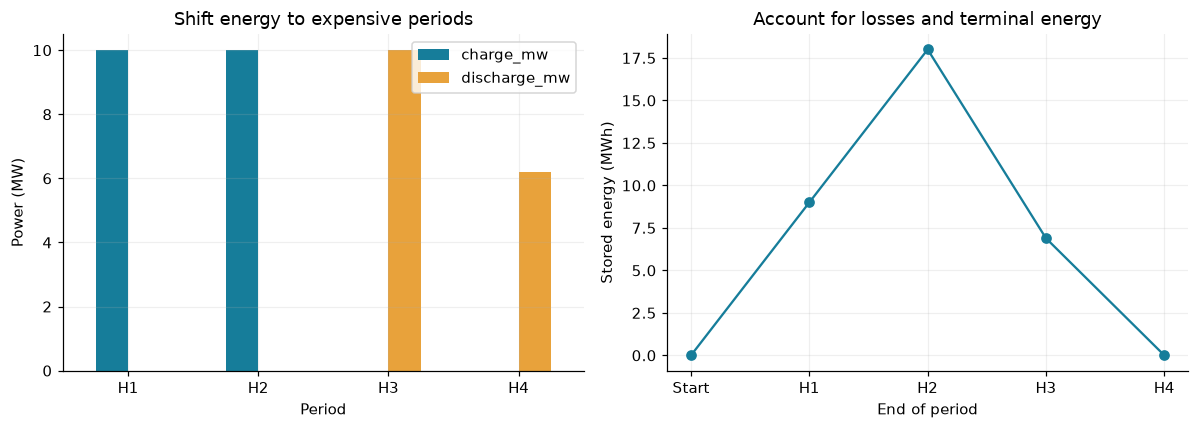

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
dispatch[["charge_mw", "discharge_mw"]].plot.bar(
    ax=axes[0], color=["#167d9a", "#e8a23b"]
)
axes[0].set(
    ylabel="Power (MW)", xlabel="Period", title="Shift energy to expensive periods"
)
axes[0].tick_params(axis="x", rotation=0)
axes[1].plot(
    ["Start", *period_names], [0, *dispatch.stored_energy_mwh], "o-", color="#167d9a"
)
axes[1].set(
    ylabel="Stored energy (MWh)",
    xlabel="End of period",
    title="Account for losses and terminal energy",
)
fig.tight_layout()
display(fig)
plt.close(fig)

## Try it

Reduce power capacity while retaining energy capacity. Then reduce energy
capacity while retaining power capacity. They constrain different parts of the
schedule. Multiple schedules may have the same cost within the two equally
priced hours, so test balances and total cost rather than one exact hourly
allocation. The example does not establish a battery's investment value.